# TMDB — Örnek Kullanım

Bu notebook `src/` modüllerinin nasıl kullanıldığını gösterir.
Yeni bir dataset veya task type ile başlamak için yalnızca **Konfigürasyon** hücresini düzenle.

| Adım | Açıklama |
|------|----------|
| 1 | Kütüphaneler & import |
| 2 | Konfigürasyon |
| 3 | Eğitim |
| 4 | Tuning |
| 5 | Test değerlendirmesi |
| 6 | Rapor |

## 1 — Kütüphaneler

In [1]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import src.modeling, src.evaluation, src.tuning, src.reporting, src.automl
for _mod in (src.modeling, src.evaluation, src.tuning, src.reporting, src.automl):
    importlib.reload(_mod)

from src.modeling import MAIN_METRIC, train_session, compare_models
from src.evaluation import evaluate_test
from src.tuning import tune_model
from src.reporting import generate_experiment_report

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [3]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = 'data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 50
FEATURE_PREFIXES = ['genre_', 'kw_']
FEATURE_VERSION  = 'v2_no_leakage'  # MLflow run'larını gruplamak için; leakage temizliği sonrası

BASE_FEATURES = [
    # Bütçe & Prodüksiyon
    'budget', 'runtime',
    'num_companies', 'num_countries',
    'is_major_studio', 'is_english', 'is_us_production',
    # Pazarlama
    'has_homepage', 'tagline_length', 'overview_length',
    # Tür
    'num_genres',
    # Takvim
    'is_summer', 'is_holiday',
    # Yönetmen geçmişi
    'director_film_count', 'director_collab_count',
]
# ──────────────────────────────────────────────────────────────

### Feature Seçimi

**Kural:** Modelde yalnızca filmin vizyona girmesinden **önce** kesin olarak bilinen özellikler kullanılır.

#### Kullanılan Özellikler (41 adet)

| Grup | Sayı | Özellikler |
|------|------|-----------|
| Sayısal / meta | 9 | `budget`, `runtime`, `num_companies`, `num_countries`, `tagline_length`, `overview_length`, `num_genres`, `director_film_count`, `director_collab_count` |
| Binary — yapısal | 6 | `is_major_studio`, `is_english`, `is_us_production`, `has_homepage`, `is_summer`, `is_holiday` |
| Binary — tür | 19 | `genre_Action` … `genre_Western` |
| Binary — keyword | 7 | `kw_based_on_novel`, `kw_woman_director`, `kw_independent_film`, `kw_3d`, `kw_sequel`, `kw_biography`, `kw_musical` |

**Notlar:**
- `director_film_count` / `director_collab_count` — temporal safe: her film için yalnızca `release_date` öncesi filmler sayılır
- `is_summer` = Haziran–Ağustos vizyonu; `is_holiday` = Kasım–Aralık vizyonu

#### Çıkarılan Özellikler

| Özellik | Gerekçe |
|---------|--------|
| `popularity`, `vote_average`, `vote_count` | Post-release — film izlendikten sonra TMDB'de oluşur |
| `has_postcredit` | Post-release — filmin izlenmesini gerektirir |
| `budget_log` | `budget` zaten mevcut; log dönüşümü tree modeller için gereksiz |
| `kw_murder`, `kw_dystopia`, `kw_violence`, `kw_revenge`, `kw_sport`, `kw_friendship`, `kw_los_angeles`, `kw_teenager`, `kw_alien`, `kw_love`, `kw_police` | Tartışmalı — kullanıcıların film izledikten sonra eklediği içerik-tabanlı etiketler |

### Veri Hazırlama *(dokunma)*

In [4]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols

df_model = df[FEATURES + [TARGET]].dropna()
X        = df_model[FEATURES]
y        = df_model[TARGET]

if TASK_TYPE == 'timeseries':
    n = len(X)
    X_train = X.iloc[:int(n * 0.70)]
    X_val   = X.iloc[int(n * 0.70):int(n * 0.85)]
    X_test  = X.iloc[int(n * 0.85):]
    y_train = y.iloc[:int(n * 0.70)]
    y_val   = y.iloc[int(n * 0.70):int(n * 0.85)]
    y_test  = y.iloc[int(n * 0.85):]
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    # 3-way split: 70 / 15 / 15
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=stratify, random_state=RANDOM_STATE,
    )
    val_frac = 0.15 / 0.85  # ~17.6% of temp → ~15% of total
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_frac,
        stratify=y_temp if TASK_TYPE in ('binary', 'multiclass') else None,
        random_state=RANDOM_STATE,
    )

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}  (~70%)')
print(f'Val      : {len(X_val):,}  (~15%) — hibrit seçimi')
print(f'Test     : {len(X_test):,}  (~15%) — yalnızca final raporu')
print(f'Özellik  : {len(FEATURES)}')

Dataset  : data/tmdb_model.csv
Task     : binary
Toplam   : 3,226  |  hit oranı: %34.8
Train    : 2,258  (~70%)
Val      : 484  (~15%) — hibrit seçimi
Test     : 484  (~15%) — yalnızca final raporu
Özellik  : 41


## 3 — Baseline Eğitimi

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260422_1657  |  task: binary


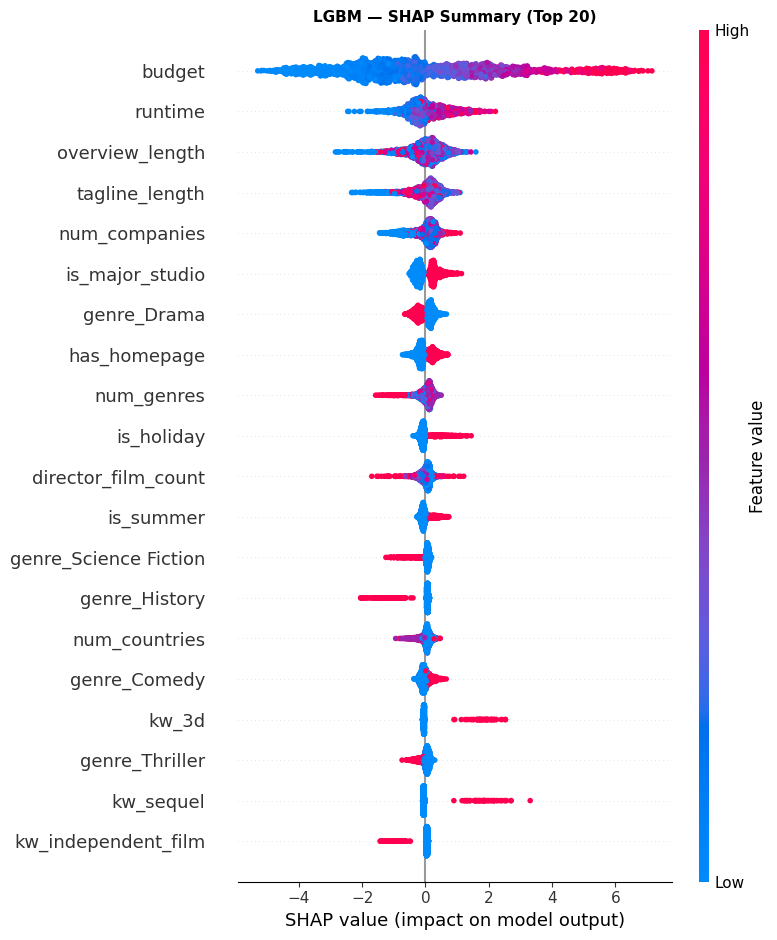

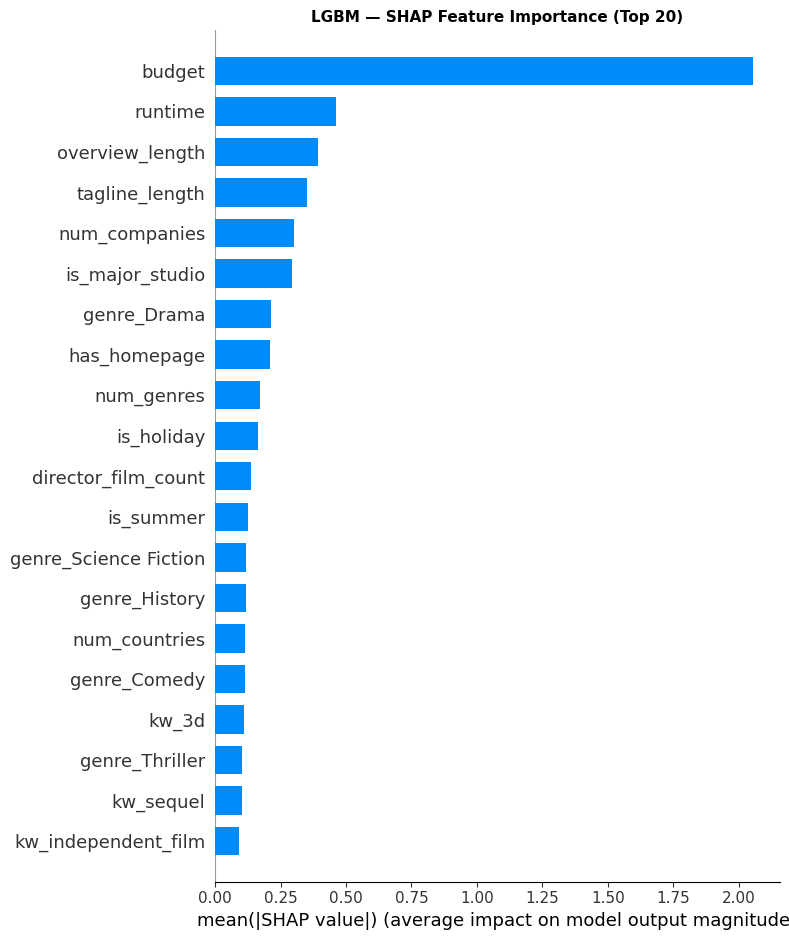

  ✓ baseline_lgbm_20260422_1657                        train=1.000  val=0.764  gap=+0.236
🏃 View run baseline_lgbm_20260422_1657 at: http://localhost:5000/#/experiments/1/runs/b8e8fa15be0049c5a3e4f08becf026d9
🧪 View experiment at: http://localhost:5000/#/experiments/1


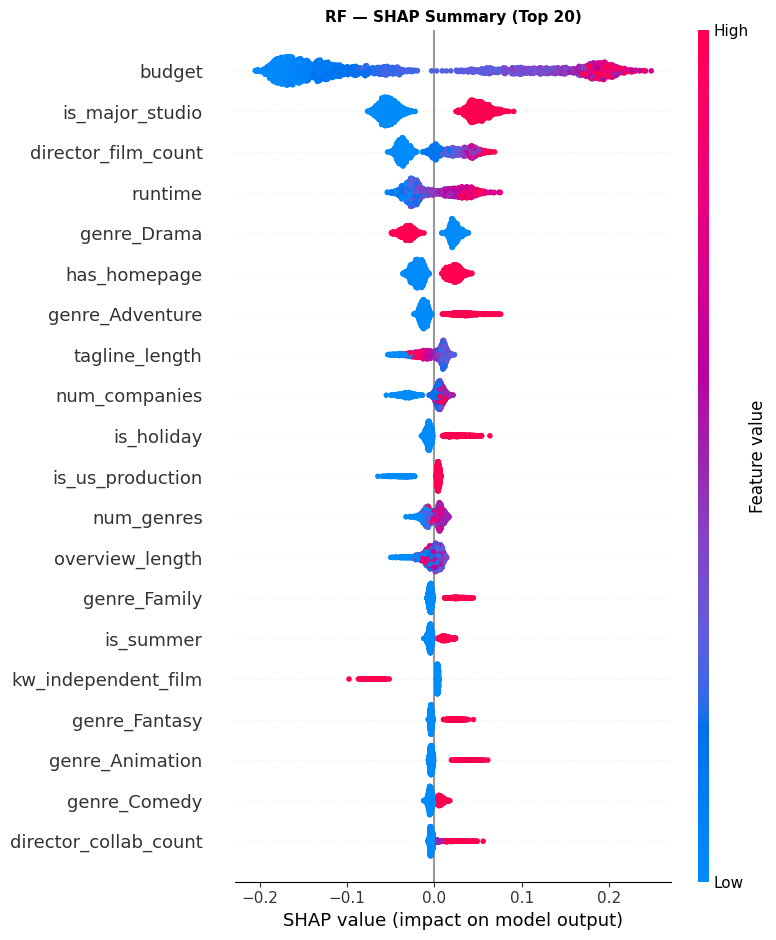

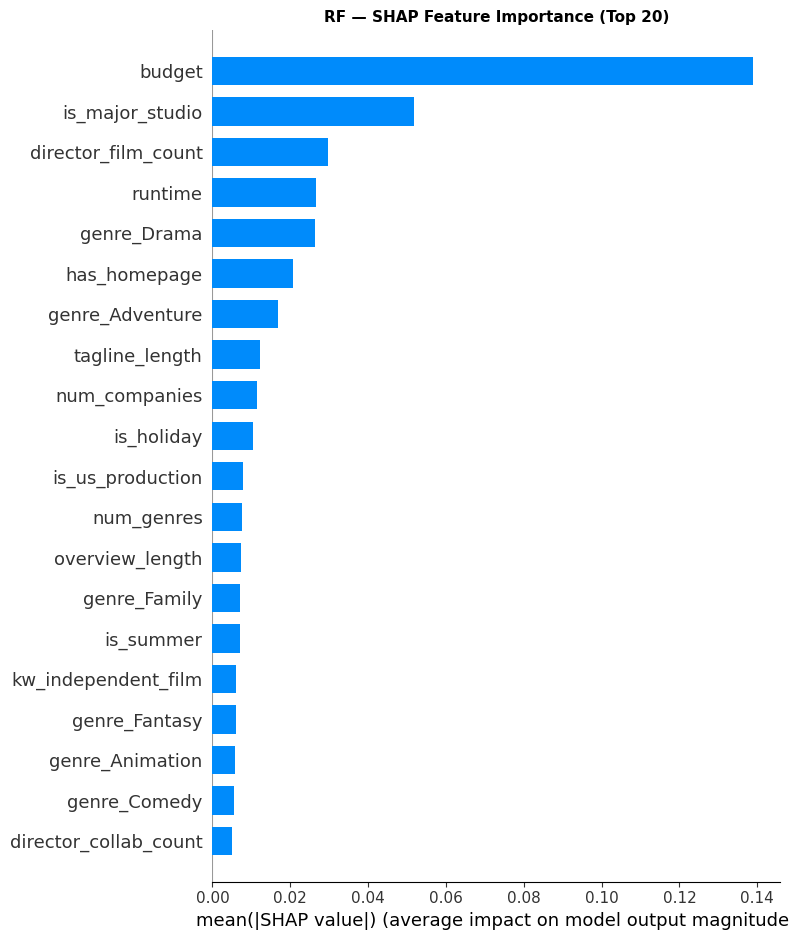

  ✓ baseline_rf_20260422_1658                          train=0.868  val=0.779  gap=+0.089
🏃 View run baseline_rf_20260422_1658 at: http://localhost:5000/#/experiments/1/runs/c6301f9670bd41e0adadc18d57b1fbe5
🧪 View experiment at: http://localhost:5000/#/experiments/1


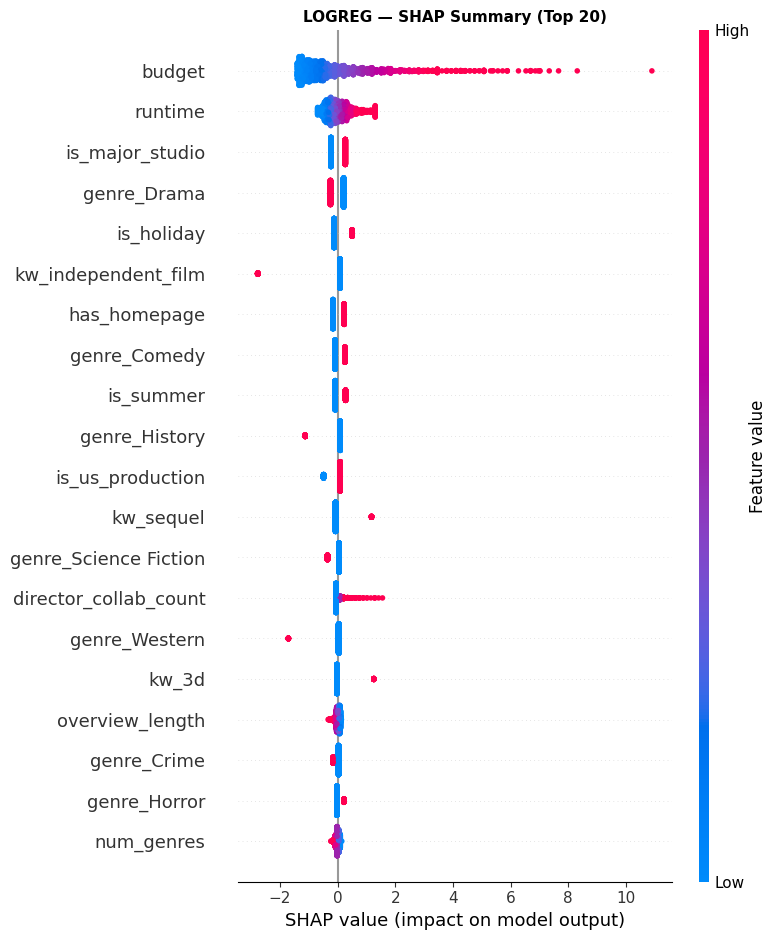

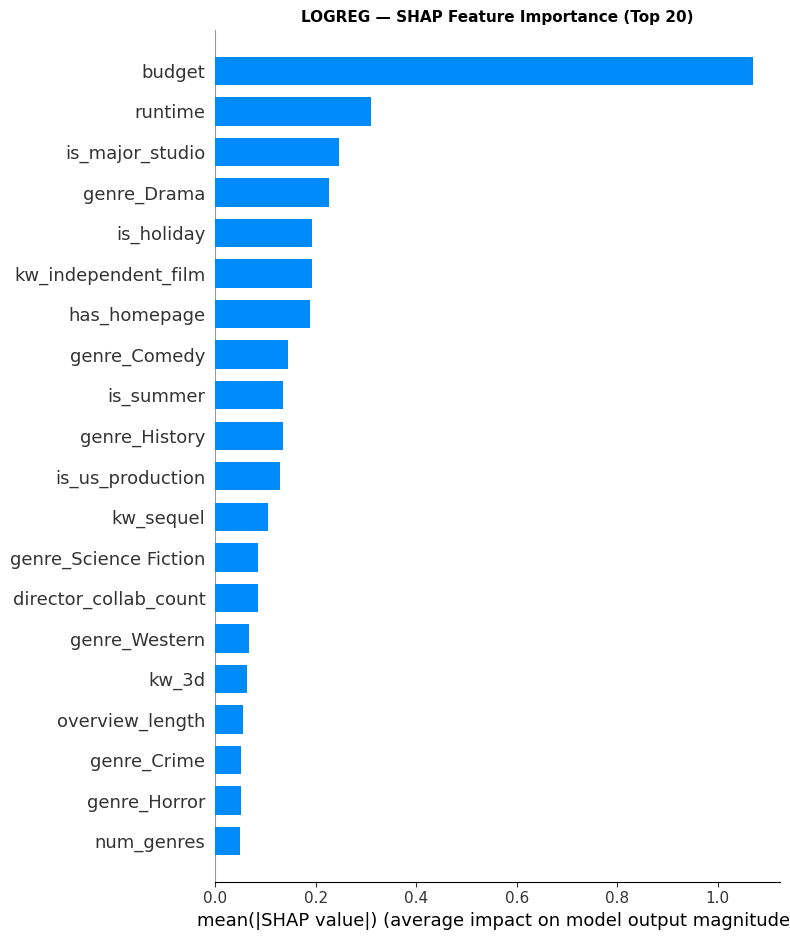

  ✓ baseline_logreg_20260422_1658                      train=0.800  val=0.788  gap=+0.012
🏃 View run baseline_logreg_20260422_1658 at: http://localhost:5000/#/experiments/1/runs/f0ae433c892c4248b3ca28b585178c32
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260422_1657 at: http://localhost:5000/#/experiments/1/runs/3f2ee3c461ed42e6b2a34f71c3a9ea29
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tamamlandı


In [5]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,PRECISION,RECALL,AVG_PREC
Model,,,,,
lgbm,0.840,0.664,0.714,0.621,0.764
rf,0.851,0.696,0.669,0.726,0.779
logreg,0.857,0.701,0.685,0.719,0.788



🏆 En iyi model: logreg  (avg_prec=0.788)
🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/fb44b3c7758142709078d52965141656
🧪 View experiment at: http://localhost:5000/#/experiments/1


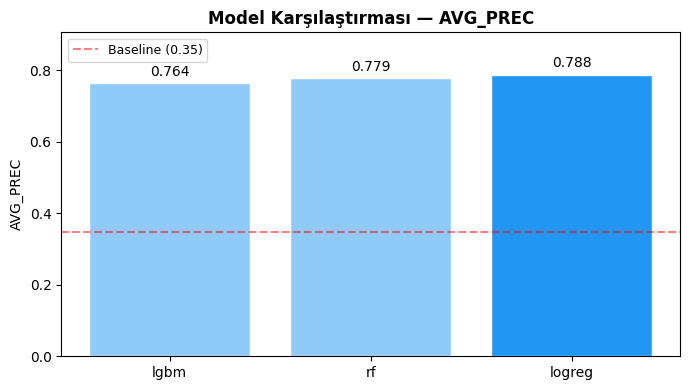


=== Overfitting / Underfitting Analizi ===


,Train AVG_PREC,Val AVG_PREC,Gap (Train−Val)
Model,,,
lgbm,1.000,0.764,0.236
rf,0.868,0.779,0.089
logreg,0.800,0.788,0.012


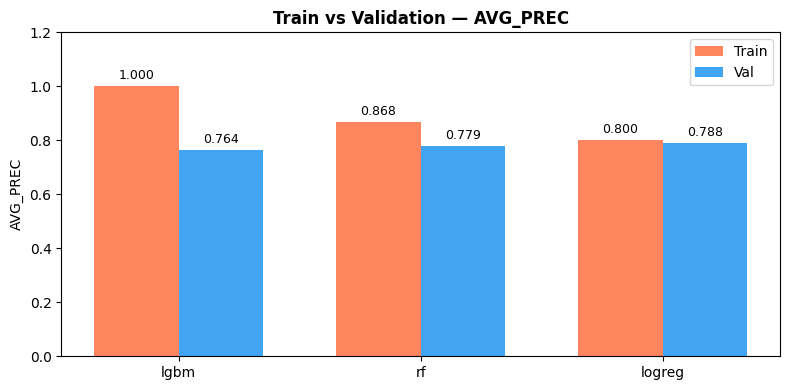

  ⚠️  lgbm: ciddi overfit (gap=0.236 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg'] — en iyi: logreg


In [6]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning (Tüm Modeller)

In [7]:
from src.automl import tune_all_models

best_model, best, tuned_models, ensemble_candidates = tune_all_models(
    results           = results,
    X                 = X_train,
    y                 = y_train,
    task_type         = TASK_TYPE,
    n_trials          = N_TRIALS,
    max_gap           = 0.10,
    X_val             = X_val,
    y_val             = y_val,
    jaccard_threshold = 0.60,
    feature_version   = FEATURE_VERSION,
)

if ensemble_candidates:
    print(f"\nEnsemble adayları: {list(ensemble_candidates.keys())}")


── Tuning: rf  (baseline=0.7785  min_improvement=0.0277) ──
Optuna başlıyor — model: rf  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7785
  Tuned     avg_prec: 0.7823
  İyileşme : +0.0038

  En iyi parametreler:
    n_estimators: 192
    max_depth: 11
    min_samples_leaf: 8
    max_features: log2
  Train-val gap: 0.0958  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_rf_20260422_1659 at: http://localhost:5000/#/experiments/1/runs/c9f3150637e84c168503eb6b0bf84c83
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned rf
  — rf: iyileşme yetersiz (+0.0038 < 0.0277) — elendi

── Tuning: logreg  (baseline=0.7885  min_improvement=0.0315) ──
Optuna başlıyor — model: logreg  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7885
  Tuned     avg_prec: 0.7887
  İyileşme : +0.0003

  En iyi parametreler:
    C: 9.357543495750932
  Train-val gap: 0.0115  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_logreg_20260422_1659 at: http://localhost:5000/#/experiments/1/runs/62d89480890749939df35c2966a16486
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned logreg
  — logreg: iyileşme yetersiz (+0.0002 < 0.0315) — elendi

⚠️  Recovery tuning: ['lgbm']  (eşik=0.2)

── Recovery Tuning: lgbm ──
Optuna başlıyor — model: lgbm  |  metrik: avg_prec  |  trial: 50  |  max_gap: 0.1


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7644
  Tuned     avg_prec: 0.7785
  İyileşme : +0.0141

  En iyi parametreler:
    n_estimators: 266
    learning_rate: 0.017681673183922726
    num_leaves: 51
    min_child_samples: 73
    reg_alpha: 0.04587014578824623
    reg_lambda: 0.014542448388410286
    subsample: 0.7042158935862007
    colsample_bytree: 0.556830118724552
  Train-val gap: 0.0884  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_lgbm_20260422_1700 at: http://localhost:5000/#/experiments/1/runs/a57047a22ce64ddeaca1e1bff65834f3
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned lgbm
  — lgbm: recovery tamamlandı (0.7785 ≤ 0.7887) — best model değişmedi

✓ tune_all_models tamamlandı — best: logreg  (avg_prec=0.7887)

── Ensemble Aday Analizi (Jaccard eşik=0.6) ──
  logreg ↔ rf: Jaccard=0.66 → atlandı (>0.6)
  logreg ↔ lgbm: Jaccard=0.70 → atlandı (>0.6)
  Yeterli çeşitlilik yok — ensemble önerilmiy

## 5 — Test Değerlendirmesi

In [ ]:
test_metrics = evaluate_test(
    best_model, X_test, y_test, TASK_TYPE, best,
    cv_metrics      = results[best]['val'],
    experiment_name = EXPERIMENT_NAME,
    feature_version = FEATURE_VERSION,
    features        = FEATURES,
    extra_tags      = {"selection_method": "val_based"},
)


## 6 — Rapor

In [9]:
from IPython.display import Markdown, display

report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

display(Markdown(report))

✓ Rapor oluşturuldu → experiment_report_20260422_170021.md
✓ MLflow'a kaydedildi → docs/experiment_report_20260422_170021.md
🏃 View run report_20260422_1700 at: http://localhost:5000/#/experiments/1/runs/77425ce703d0459ebeabc96c37c624ea
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Experiment Raporu — tmdb_model

**Oluşturulma:** 2026-04-22 17:00  
**Task:** binary  
**Ana Metrik:** avg_prec  
**Dataset:** data/tmdb_model.csv  
**Toplam Film:** 3,226  |  **Hit Oranı:** %34.8  
**Özellik Sayısı:** 41  

---

## Baseline Sonuçları

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|----|-----------|----|
| logreg | 0.788 | 0.857 | 0.701 | 0.685 | 0.719 |
| rf | 0.779 | 0.851 | 0.696 | 0.669 | 0.726 |
| lgbm | 0.764 | 0.840 | 0.664 | 0.714 | 0.621 |

---

## Tuning

- **lgbm** — Baseline avg_prec: 0.764 → Tuned: 0.778 (İyileşme: 0.014)
- **logreg** — Baseline avg_prec: 0.788 → Tuned: 0.789 (İyileşme: 0.000)
- **rf** — Baseline avg_prec: 0.779 → Tuned: 0.782 (İyileşme: 0.004)

---

## Test Seti Sonuçları

| Metrik | Değer |
|--------|-------|
| F1 | 0.698 |
| PRECISION | 0.656 |
| RECALL | 0.746 |
| PR_AUC | 0.784 |
| ROC_AUC | 0.854 |

## 7 — Hibrit Modeller

Baseline modellerin (LGBM, RF, LogReg) güçlü yönlerini birleştirmek için üç strateji deneniyor.

| Yöntem | Fikir | Artısı | Eksi |
|--------|-------|--------|------|
| **Voting** | Olasılıkların ağırlıklı ortalaması | Basit, hızlı, yorumlanabilir | Modeller aynı hatayı paylaşabilir |
| **Stacking** | CV ile out-of-fold meta-özellik → meta-model | En güçlü kombinasyon | Yavaş, dikkatli CV gerektirir |
| **Blending** | Holdout meta-özellik → meta-model (CV yok) | Hızlı, leakage riski düşük | Daha az veri verimli |

In [10]:
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score, recall_score

ir = (y_train == 0).sum() / (y_train == 1).sum()

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    )

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

def quick_val_metrics(model, X, y):
    """Val/test seti için sızıntısız metrik hesabı — MLflow kaydı yok."""
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return {
        "PR-AUC":    average_precision_score(y, proba),
        "ROC-AUC":   roc_auc_score(y, proba),
        "F1":        f1_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
    }

print(f'✓ Base model factory hazır  |  imbalance_ratio: {ir:.3f}')
print('✓ quick_val_metrics hazır')

✓ Base model factory hazır  |  imbalance_ratio: 1.873
✓ quick_val_metrics hazır


### 7a — Voting Ensemble

`VotingClassifier(voting='soft')` her modelin olasılık tahminlerini ağırlıklı ortalamayla birleştirir.
LGBM baseline'da en güçlü performansı gösterdiği için `weights=[2, 1, 1]` kullanıyoruz.

In [11]:
# Top-2 seçimi: val avg_prec sıralaması
ranked = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("avg_prec", 0),
    reverse=True,
)[:2]

scores  = {name: results[name]["val"]["avg_prec"] for name in ranked}
weights = [scores[name] for name in ranked]

print(f"Voting top-2 : {ranked}")
print(f"Weights      : {[f'{w:.4f}' for w in weights]}")

voting_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked],
    voting="soft",
    weights=weights,
    n_jobs=1,
)
voting_clf.fit(X_train, y_train)
voting_val_metrics = quick_val_metrics(voting_clf, X_val, y_val)
print(f"Val PR-AUC   : {voting_val_metrics['PR-AUC']:.4f}")

# Top-3: tüm tuned modeller
ranked3  = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("avg_prec", 0),
    reverse=True,
)
scores3  = {name: results[name]["val"]["avg_prec"] for name in ranked3}
weights3 = [scores3[name] for name in ranked3]

print(f"\nVoting top-3 : {ranked3}")
print(f"Weights      : {[f'{w:.4f}' for w in weights3]}")

voting3_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked3],
    voting="soft",
    weights=weights3,
    n_jobs=1,
)
voting3_clf.fit(X_train, y_train)
voting3_val_metrics = quick_val_metrics(voting3_clf, X_val, y_val)
print(f"Val PR-AUC   : {voting3_val_metrics['PR-AUC']:.4f}")

Voting top-2 : ['logreg', 'rf']
Weights      : ['0.7885', '0.7785']
Val PR-AUC   : 0.8033

Voting top-3 : ['logreg', 'rf', 'lgbm']
Weights      : ['0.7885', '0.7785', '0.7644']
Val PR-AUC   : 0.7984


### 7b — Stacking

`StackingClassifier` her base modeli 5-fold CV ile eğitip out-of-fold tahminlerini
meta-özellik olarak kullanır. Meta-model (LogisticRegression) bu özelliklerden öğrenir.

In [12]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lgbm',   clone(tuned_models['lgbm'])),
        ('rf',     clone(tuned_models['rf'])),
        ('logreg', clone(tuned_models['logreg'])),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)
stacking_val_metrics = quick_val_metrics(stacking_clf, X_val, y_val)
print(f"Stacking Val PR-AUC: {stacking_val_metrics['PR-AUC']:.4f}")

Stacking Val PR-AUC: 0.8001


### 7c — Blending

Train setinin %20'si **holdout** olarak ayrılır. Base modeller kalan %80 üzerinde eğitilir;
holdout tahminleri meta-model için girdi oluşturur. Stacking'e kıyasla daha hızlı ama
daha az veri verimlidir.

In [13]:
class BlendingEnsemble:
    """
    Blending stratejisi:
      1. X_train → blend_train (%80) + holdout (%20) olarak bölünür.
      2. Base modeller yalnızca blend_train üzerinde eğitilir.
      3. Holdout tahminleri (predict_proba) meta-özellik matrisini oluşturur.
      4. Meta-model bu matris üzerinde eğitilir.
      5. Test tahminleri: base modeller test setini tahmin eder → meta-model birleştirir.

    Stacking'den farkı: CV yoktur; bilgi sızıntısını önlemek için ayrı bir holdout kullanılır.
    """

    def __init__(self, base_models: list, meta_model, blend_ratio: float = 0.2,
                 random_state: int = 42):
        self.base_models  = base_models   # [(isim, estimator), ...]
        self.meta_model   = meta_model
        self.blend_ratio  = blend_ratio
        self.random_state = random_state

    def fit(self, X, y):
        from sklearn.model_selection import train_test_split
        X_bt, X_hold, y_bt, y_hold = train_test_split(
            X, y,
            test_size=self.blend_ratio,
            stratify=y,
            random_state=self.random_state,
        )
        for _, m in self.base_models:
            m.fit(X_bt, y_bt)

        meta_train = np.column_stack([
            m.predict_proba(X_hold)[:, 1] for _, m in self.base_models
        ])
        self.meta_model.fit(meta_train, y_hold)
        return self

    def predict_proba(self, X):
        meta = np.column_stack([
            m.predict_proba(X)[:, 1] for _, m in self.base_models
        ])
        prob1 = self.meta_model.predict_proba(meta)[:, 1]
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('✓ BlendingEnsemble sınıfı tanımlandı')

✓ BlendingEnsemble sınıfı tanımlandı


In [14]:
blending_clf = BlendingEnsemble(
    base_models=[(name, clone(tuned_models[name])) for name in tuned_models],
    meta_model=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    blend_ratio=0.2,
    random_state=RANDOM_STATE,
)
blending_clf.fit(X_train, y_train)
blending_val_metrics = quick_val_metrics(blending_clf, X_val, y_val)
print(f"Blending Val PR-AUC: {blending_val_metrics['PR-AUC']:.4f}")

Blending Val PR-AUC: 0.8031


### Tüm Hibrit Modellerin Karşılaştırması

=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===


,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,
best_single (logreg),0.8004,0.8569,0.7147,0.6719,0.7633
voting_top2,0.8033,0.8608,0.7283,0.6915,0.7692
voting_top3,0.7984,0.8574,0.7278,0.6859,0.7751
stacking,0.8001,0.8586,0.6997,0.7338,0.6686
blending,0.8031,0.8585,0.7059,0.7403,0.6746


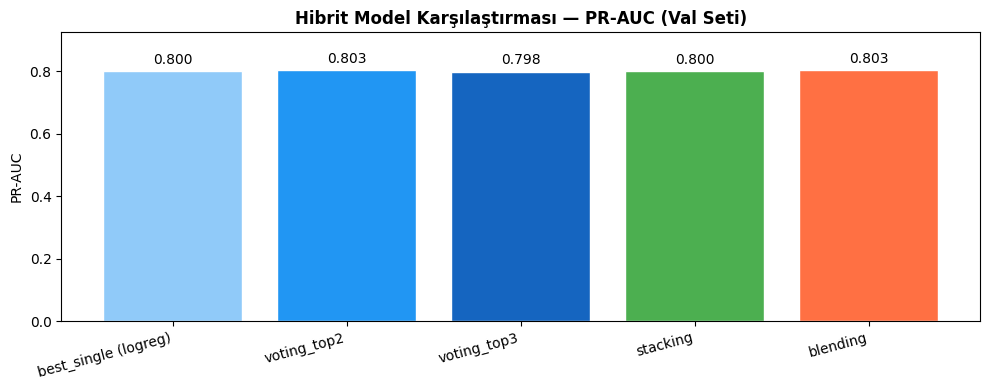

In [15]:
metric_col = "PR-AUC"
best_single_val_metrics = quick_val_metrics(best_model, X_val, y_val)

hybrid_val_results = {
    f"best_single ({best})": best_single_val_metrics,
    "voting_top2":           voting_val_metrics,
    "voting_top3":           voting3_val_metrics,
    "stacking":              stacking_val_metrics,
    "blending":              blending_val_metrics,
}

rows = []
for name, m in hybrid_val_results.items():
    rows.append({"Model": name, **{k: round(v, 4) for k, v in m.items()}})
comparison_df = pd.DataFrame(rows).set_index("Model")
print("=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===")
display(comparison_df)

vals   = [m.get(metric_col, 0) for m in hybrid_val_results.values()]
labels = list(hybrid_val_results.keys())
colors = ["#90CAF9", "#2196F3", "#1565C0", "#4CAF50", "#FF7043"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_title(f"Hibrit Model Karşılaştırması — {metric_col} (Val Seti)", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_ylabel(metric_col)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Final Model Seçimi

In [ ]:
all_candidates = {
    f"best_single ({best})": (best_model,   best_single_val_metrics),
    "voting_top2":           (voting_clf,   voting_val_metrics),
    "voting_top3":           (voting3_clf,  voting3_val_metrics),
    "stacking":              (stacking_clf, stacking_val_metrics),
    "blending":              (blending_clf, blending_val_metrics),
}

main_metric_key = "PR-AUC"
final_name  = max(all_candidates, key=lambda n: all_candidates[n][1].get(main_metric_key, 0))
final_model = all_candidates[final_name][0]
final_val   = all_candidates[final_name][1]

print("=== Final Model (val seti seçimi — sızıntısız) ===")
print(f"  Model       : {final_name}")
print(f"  Val {main_metric_key} : {final_val[main_metric_key]:.4f}")
print()

# evaluate_test yalnızca seçilen model için X_test üzerinde çağrılır
if "best_single" in final_name:
    final_metrics = test_metrics  # cell 2b97424c'de hesaplandı
else:
    final_metrics = evaluate_test(
        final_model, X_test, y_test, TASK_TYPE,
        final_name.replace(" ", "_").replace("(", "").replace(")", ""),
        cv_metrics      = results[best]["val"],
        experiment_name = EXPERIMENT_NAME,
        feature_version = FEATURE_VERSION,
        extra_tags      = {"selection_method": "val_based"},
    )

print("=== Test Skoru (yalnızca seçilen model) ===")
for k, v in final_metrics.items():
    print(f"  {k:<12}: {v:.4f}")


In [ ]:
import json, tempfile
from collections import defaultdict
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp    = client.get_experiment_by_name(EXPERIMENT_NAME)

if exp:
    eid = exp.experiment_id

    # ── Champion Tracking ────────────────────────────────────────────
    # Yalnızca val_based seçim metoduyla kaydedilen run'lar — leaky_test etiketliler hariç
    val_based_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string=(
            f"tags.stage = 'test' "
            f"AND tags.feature_version = '{FEATURE_VERSION}' "
            f"AND tags.selection_method = 'val_based'"
        ),
        order_by=["metrics.test_pr_auc DESC"],
    )

    curr_score = final_metrics.get('PR-AUC', 0)

    if val_based_runs:
        champion   = val_based_runs[0]
        hist_score = champion.data.metrics.get('test_pr_auc', 0)
        delta      = curr_score - hist_score
        symbol     = "Yeni şampiyon!" if delta > 0 else "Geçilemedi"
        print("=== Champion Tracking (val_based) ===")
        print(f"  Geçmiş en iyi  : {hist_score:.4f}  ({champion.info.run_name})")
        print(f"  Mevcut         : {curr_score:.4f}  ({final_name})")
        print(f"  Fark           : {delta:+.4f}  — {symbol}")

        artifact_names = {a.path for a in client.list_artifacts(champion.info.run_id)}
        if "features.json" in artifact_names:
            try:
                with tempfile.TemporaryDirectory() as tmp:
                    path = client.download_artifacts(champion.info.run_id, "features.json", tmp)
                    with open(path) as f:
                        hist_features = set(json.load(f)["features"])
                curr_features = set(FEATURES)
                added   = sorted(curr_features - hist_features)
                removed = sorted(hist_features - curr_features)
                print(f"\n=== Feature Karşılaştırması ===")
                print(f"  Geçmiş : {len(hist_features)} feature")
                print(f"  Mevcut : {len(curr_features)} feature")
                if added:
                    print(f"  Eklenen  (+{len(added)}): {', '.join(added)}")
                if removed:
                    print(f"  Çıkarılan (-{len(removed)}): {', '.join(removed)}")
                if not added and not removed:
                    print("  Feature seti değişmedi.")
            except Exception:
                pass
        else:
            print("\n  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)")
    else:
        champion = None
        print("=== Champion Tracking (val_based) ===")
        print(f"  İlk val_based run — referans skor: {curr_score:.4f}  ({final_name})")
        print(f"  Feature sayısı: {len(FEATURES)}")

    # ── Genel MLflow Temizliği ────────────────────────────────────────

    # 1. Tüm test run'ları çek; leaky_test ve şampiyon korunur, diğerleri silinir
    all_test_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.stage = 'test'",
        order_by=["metrics.test_pr_auc DESC"],
    )
    champion_id = champion.info.run_id if champion else None
    stale_test  = [
        r for r in all_test_runs
        if r.info.run_id != champion_id
        and r.data.tags.get("selection_method") != "leaky_test"
    ]
    for r in stale_test:
        client.delete_run(r.info.run_id)
    if stale_test:
        print(f"\n✓ {len(stale_test)} eski test run'ı silindi — şampiyon ve leaky_test korundu")

    # 2. Summary, report, session — türetilmiş bilgi, tümünü sil
    for run_type in ("summary", "report", "session"):
        to_del = list(client.search_runs(
            experiment_ids=[eid],
            filter_string=f"tags.type = '{run_type}'",
        ))
        for r in to_del:
            client.delete_run(r.info.run_id)
        if to_del:
            print(f"✓ {len(to_del)} {run_type} run'ı silindi")

    # 3. Tuning — model başına en yüksek skoru koru (tüm era dahil)
    tuning_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'tuning'",
        order_by=["metrics.tuned_avg_prec DESC"],
    )
    by_model = defaultdict(list)
    for r in tuning_runs:
        by_model[r.data.tags.get("model_type", "unknown")].append(r)

    tuning_deleted = 0
    for runs in by_model.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            tuning_deleted += 1
    if tuning_deleted:
        print(f"✓ {tuning_deleted} eski tuning run'ı silindi — model başına 1 korundu")

    # 4. Baseline — model başına en son run'ı koru (tüm era dahil)
    baseline_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'baseline'",
        order_by=["start_time DESC"],
    )
    by_model_bl = defaultdict(list)
    for r in baseline_runs:
        by_model_bl[r.data.tags.get("model_type", "unknown")].append(r)

    baseline_deleted = 0
    for runs in by_model_bl.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            baseline_deleted += 1
    if baseline_deleted:
        print(f"✓ {baseline_deleted} eski baseline run'ı silindi — model başına 1 korundu")

    # 5. Bilinmeyen tip run'lar (feature_selection vb.) — tümünü sil
    known_types  = {"test_evaluation", "tuning", "baseline", "summary", "report", "session"}
    all_runs     = client.search_runs(experiment_ids=[eid])
    other_deleted = 0
    for r in all_runs:
        tags      = r.data.tags
        run_type  = tags.get("type", "")
        run_stage = tags.get("stage", "")
        is_known  = run_type in known_types or run_stage == "test"
        if not is_known and r.info.run_id != champion_id:
            client.delete_run(r.info.run_id)
            other_deleted += 1
    if other_deleted:
        print(f"✓ {other_deleted} diğer run silindi (feature_selection vb.)")

else:
    print(f"MLflow experiment '{EXPERIMENT_NAME}' bulunamadı.")


### ADVBK-47 — Final Seçim Stratejisi Analizi

**ADVBK-48 sonrası:** 3'lü veri bölmesi uygulandı; val metrikleri artık ayrı bir holdout setten (X_val, ~%15) hesaplanıyor. Seçenek A artık sızıntısız.

Bu hücre üç seçenek altında hangi modelin kazandığını ve hibritlerin gerçek val üstünlüğünü gösterir.

| Seçenek | Kriter | Sızıntı? |
|---------|--------|----------|
| **A (mevcut)** | Holdout val PR-AUC — sızıntısız | ✓ Hayır |
| **B (proxy CV)** | Bileşen val avg_prec ortalaması | ✓ Hayır |
| **C (single CV)** | Yalnızca tekil modeller, CV skoru en yüksek | ✓ Hayır |

In [18]:
print("=== ADVBK-47: Final Seçim Stratejisi Analizi (ADVBK-48 sonrası) ===\n")

val_scores = {name: results[name]["val"]["avg_prec"] for name in results}

# Val PR-AUC (honest — X_val holdout üzerinde ölçüldü)
val_pr_auc_map = {
    f"best_single ({best})": best_single_val_metrics["PR-AUC"],
    "voting_top2":           voting_val_metrics["PR-AUC"],
    "voting_top3":           voting3_val_metrics["PR-AUC"],
    "stacking":              stacking_val_metrics["PR-AUC"],
    "blending":              blending_val_metrics["PR-AUC"],
}

# Seçenek A (mevcut): holdout val PR-AUC'ya göre — sızıntısız
winner_a = max(val_pr_auc_map, key=val_pr_auc_map.get)

# Seçenek B: proxy CV (bileşen val avg_prec ortalaması)
proxy_b = {
    f"best_single ({best})": val_scores[best],
    "voting_top2":  sum(val_scores[n] for n in ranked)  / len(ranked),
    "voting_top3":  sum(val_scores[n] for n in ranked3) / len(ranked3),
    "stacking":     sum(val_scores.values()) / len(val_scores),
    "blending":     sum(val_scores.values()) / len(val_scores),
}
winner_b = max(proxy_b, key=proxy_b.get)

# Seçenek C: yalnızca tekil model
winner_c = f"best_single ({best})"

# Val PR-AUC tablosu
print("Val PR-AUC (holdout val seti — sızıntısız):")
for name, score in sorted(val_pr_auc_map.items(), key=lambda x: -x[1]):
    print(f"  {name:<26}: {score:.4f}")
print()

# Proxy CV tablosu
print("Proxy CV skorları (Seçenek B için):")
for name, score in proxy_b.items():
    print(f"  {name:<26}: {score:.4f}")
print()

# Karşılaştırma
COL = f"{'Seçenek':<15} {'Kriter':<32} {'Seçilen Model':<26} {'Val PR-AUC':>10}"
print(COL)
print("─" * len(COL))
print(f"{'A (mevcut)':<15} {'Holdout val PR-AUC':<32} {winner_a:<26} {val_pr_auc_map[winner_a]:>10.4f}")
print(f"{'B (proxy CV)':<15} {'Bileşen val avg_prec ort.':<32} {winner_b:<26} {val_pr_auc_map[winner_b]:>10.4f}")
print(f"{'C (single CV)':<15} {'Yalnızca tekil model CV':<32} {winner_c:<26} {val_pr_auc_map[winner_c]:>10.4f}")

print()
gap_ab = val_pr_auc_map[winner_a] - val_pr_auc_map[winner_b]
gap_bc = val_pr_auc_map[winner_b] - val_pr_auc_map[winner_c]
print(f"Hibrit gerçek üstünlüğü (A vs B): {gap_ab:+.4f}"
      + ("  ← hibrit gerçekten daha iyi" if gap_ab > 0 else "  ← tekil model kazanıyor"))
print(f"Proxy CV uyumu (B vs C)          : {gap_bc:+.4f}")

=== ADVBK-47: Final Seçim Stratejisi Analizi (ADVBK-48 sonrası) ===

Val PR-AUC (holdout val seti — sızıntısız):
  voting_top2               : 0.8033
  blending                  : 0.8031
  best_single (logreg)      : 0.8004
  stacking                  : 0.8001
  voting_top3               : 0.7984

Proxy CV skorları (Seçenek B için):
  best_single (logreg)      : 0.7885
  voting_top2               : 0.7835
  voting_top3               : 0.7771
  stacking                  : 0.7771
  blending                  : 0.7771

Seçenek         Kriter                           Seçilen Model              Val PR-AUC
──────────────────────────────────────────────────────────────────────────────────────
A (mevcut)      Holdout val PR-AUC               voting_top2                    0.8033
B (proxy CV)    Bileşen val avg_prec ort.        best_single (logreg)           0.8004
C (single CV)   Yalnızca tekil model CV          best_single (logreg)           0.8004

Hibrit gerçek üstünlüğü (A vs B): +0.0029  